## 1. Download & extract dataset

In [9]:
!pip install -q gdown
import gdown
import zipfile
import os

file_id = '1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs'
zip_file = 'EyeDiseaseDataset.zip'
gdown.download(id=file_id, output=zip_file, quiet=False, fuzzy=True)

extract_path = './dataset'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))


Downloading...
From (original): https://drive.google.com/uc?id=1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs
From (redirected): https://drive.google.com/uc?id=1zaznBnFm3PnHy_9WQBhgjF_HLwb7L9Zs&confirm=t&uuid=471d75f6-4682-4e7e-87fe-0135653f7e41
To: /kaggle/working/EyeDiseaseDataset.zip
100%|██████████| 4.08G/4.08G [00:39<00:00, 103MB/s] 


['images', 'Tasks_and_Classes.md', 'metadata.csv', 'splits', 'catalog']


**Alternative source: mount from Google Drive instead** — run this cell *instead of* the `gdown` cell above if you already have `EyeDiseaseDataset.zip` saved in your Drive. Don't run both.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/EyeDiseaseDataset.zip'
extract_path = './dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete!")


## 2. Imports

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve

print("TF version:", tf.__version__)
print("GPUs/TPUs visible:", tf.config.list_physical_devices())


TF version: 2.20.0
GPUs/TPUs visible: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3. Load metadata

In [12]:
def merge_data(image_dir, data_path):
    df = pd.read_csv(data_path)
    df['full_path'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))
    df['exists'] = df['full_path'].apply(os.path.exists)
    df = df[df['exists']].reset_index(drop=True)
    return df


In [13]:
image_dir = './dataset/images'
metadata_path = './dataset/metadata.csv'

df = merge_data(image_dir, metadata_path)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filename        11839 non-null  object
 1   dataset         11839 non-null  object
 2   unified_label   11839 non-null  object
 3   original_label  11839 non-null  object
 4   full_path       11839 non-null  object
 5   exists          11839 non-null  bool  
dtypes: bool(1), object(5)
memory usage: 474.2+ KB


## 4. Class distribution — before cleaning

/tmp/ipykernel_3372/1651003920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='original_label', palette='viridis')


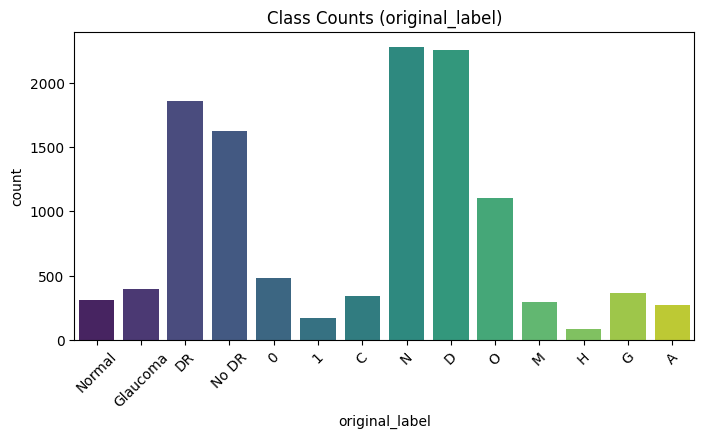

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='original_label', palette='viridis')
plt.title('Class Counts (original_label)')
plt.xticks(rotation=45)
plt.show()


## 5. Unify / clean labels

In [14]:
label_map = {

    '0': 'Normal',
    'N': 'Normal',
    'NO DR': 'Normal',
    'No DR':'Normal',
    'NORMAL': 'Normal',
    'Normal': 'Normal',

    '1': 'Diabetic Retinopathy',
    'D': 'Diabetic Retinopathy',
    'DR': 'Diabetic Retinopathy',
    'Diabetic Retinopathy': 'Diabetic Retinopathy',

    'G': 'Glaucoma',
    'Glaucoma' :'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Others'
}

def clean_label(df_):
    df_['clean_label'] = df_['original_label'].astype(str).str.strip().map(label_map)
    return df_

df = clean_label(df)
unmapped_labels = df[df['clean_label'].isna()]['original_label'].unique()
print("Remaining unmapped classes:", unmapped_labels)
print("\nFinal Unified Counts:")
print(df['clean_label'].value_counts())


Remaining unmapped classes: []

Final Unified Counts:
clean_label
Normal                  4698
Diabetic Retinopathy    4281
Others                  1102
Glaucoma                 762
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


/tmp/ipykernel_3372/2657768779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='clean_label', palette='viridis')


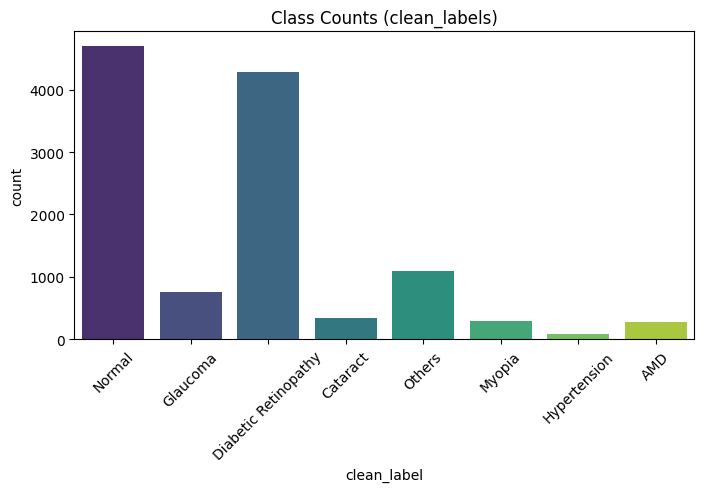

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='clean_label', palette='viridis')
plt.title('Class Counts (clean_labels)')
plt.xticks(rotation=45)
plt.show()


## 6. Sample images per class (sanity check)

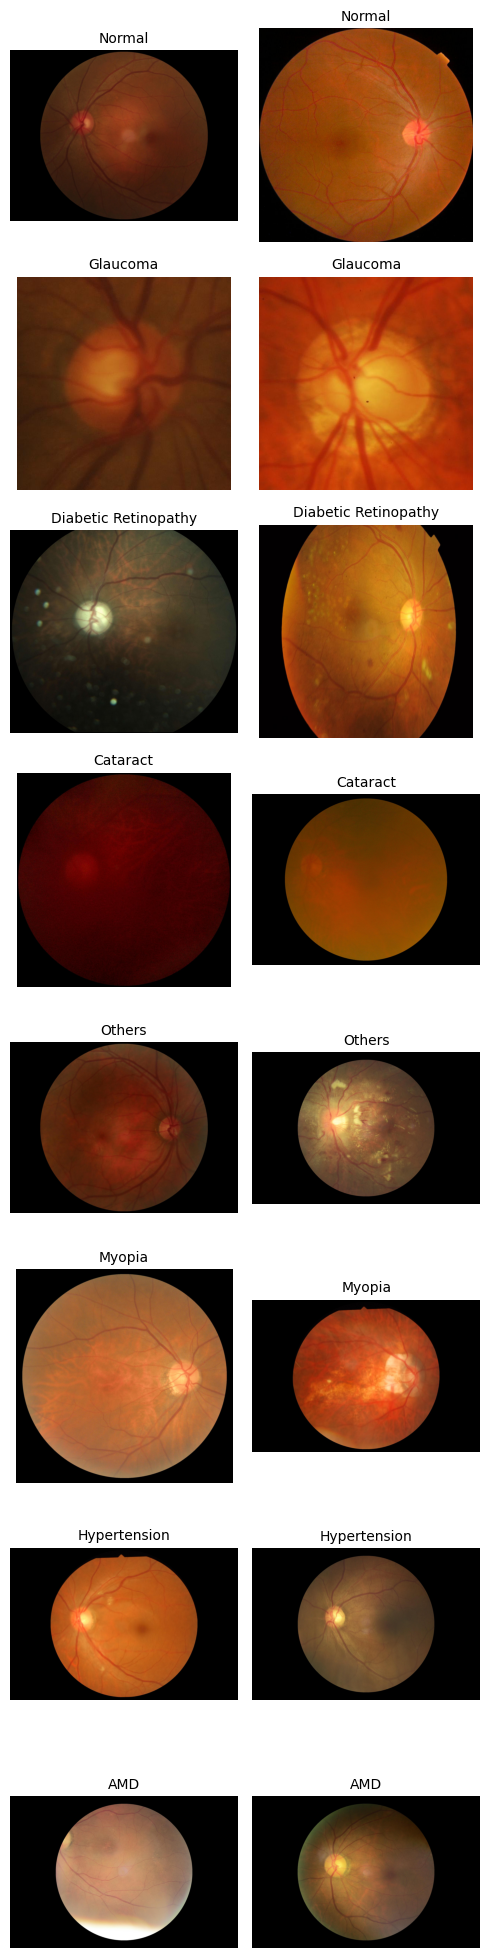

In [8]:
def show_samples_per_class(df, samples_per_class=2, random_state=42):
    unique_classes = df['clean_label'].unique()
    fig, axes = plt.subplots(
        nrows=len(unique_classes), ncols=samples_per_class,
        figsize=(samples_per_class * 2.5, len(unique_classes) * 2.5), squeeze=False
    )
    for row_idx, class_name in enumerate(unique_classes):
        class_df = df[df['clean_label'] == class_name]
        sampled_rows = class_df.sample(n=min(samples_per_class, len(class_df)), random_state=random_state)
        for col_idx in range(samples_per_class):
            axes[row_idx, col_idx].axis('off')
        for col_idx, (_, row) in enumerate(sampled_rows.iterrows()):
            img = Image.open(row['full_path'])
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(class_name, fontsize=10)
            axes[row_idx, col_idx].axis('off')
    plt.tight_layout()
    plt.show()

show_samples_per_class(df, samples_per_class=2, random_state=42)


## 7. Encode labels + derive the Stage-1 target

`encoded_label` is the full 8-class encoding (used for the end-to-end evaluation and Stage 2's label space later). `is_disease` is Stage 1's binary target.

In [15]:
def encoding(df_):
    label_encoder = LabelEncoder()
    df_['encoded_label'] = label_encoder.fit_transform(df_['clean_label'])
    class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    return class_mapping, df_

class_mapping, df = encoding(df)
print("Full 8-class index mapping:", class_mapping)

df['is_disease'] = (df['clean_label'] != 'Normal').astype(int)
print("\nis_disease counts:\n", df['is_disease'].value_counts())
df.head()


Full 8-class index mapping: {'AMD': np.int64(0), 'Cataract': np.int64(1), 'Diabetic Retinopathy': np.int64(2), 'Glaucoma': np.int64(3), 'Hypertension': np.int64(4), 'Myopia': np.int64(5), 'Normal': np.int64(6), 'Others': np.int64(7)}

is_disease counts:
 is_disease
1    7141
0    4698
Name: count, dtype: int64


,filename,dataset,unified_label,original_label,full_path,exists,clean_label,encoded_label,is_disease
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im001_ACRIMA.jpg,True,Normal,6,0
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im002_ACRIMA.jpg,True,Normal,6,0
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im003_ACRIMA.jpg,True,Normal,6,0
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im004_ACRIMA.jpg,True,Normal,6,0
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal,./dataset/images/ACRIMA_Im005_ACRIMA.jpg,True,Normal,6,0


## 8. Train / Test split — use the dataset's official split if provided, else fall back to stratified

**Merged from the second notebook.** If `./dataset/splits/val.csv` exists, it's the dataset's own predefined holdout — using it beats an ad-hoc random split because it's reproducible and (usually) leak-checked by whoever built the dataset. If that file isn't present, this falls back to the same stratified `train_test_split` v3 used, so nothing breaks on datasets without an official split.

In [16]:
#official_val_path = './dataset/splits/val.csv'
NUM_CLASSES_FULL = df['clean_label'].nunique()

# if os.path.exists(official_val_path):
#     val_meta = pd.read_csv(official_val_path)
#     val_filenames = set(val_meta['filename'].tolist())
#     df['split'] = df['filename'].apply(lambda x: 'val' if x in val_filenames else 'train')

#     train_df = df[df['split'] == 'train'].reset_index(drop=True)
#     test_df = df[df['split'] == 'val'].reset_index(drop=True)
#     print(f"Using official split from {official_val_path}")
# else:
train_df, test_df = train_test_split(
        df, test_size=0.20, random_state=42, stratify=df['clean_label'])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
    # print(f"No official split found at {official_val_path} -- falling back to a stratified 80/20 split")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (9471, 9)
Test shape: (2368, 9)


## 9. Train vs. Test distribution

/tmp/ipykernel_3372/2487715092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='clean_label', palette='viridis', ax=axes[0], order=order)
/tmp/ipykernel_3372/2487715092.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='clean_label', palette='viridis', ax=axes[1], order=order)


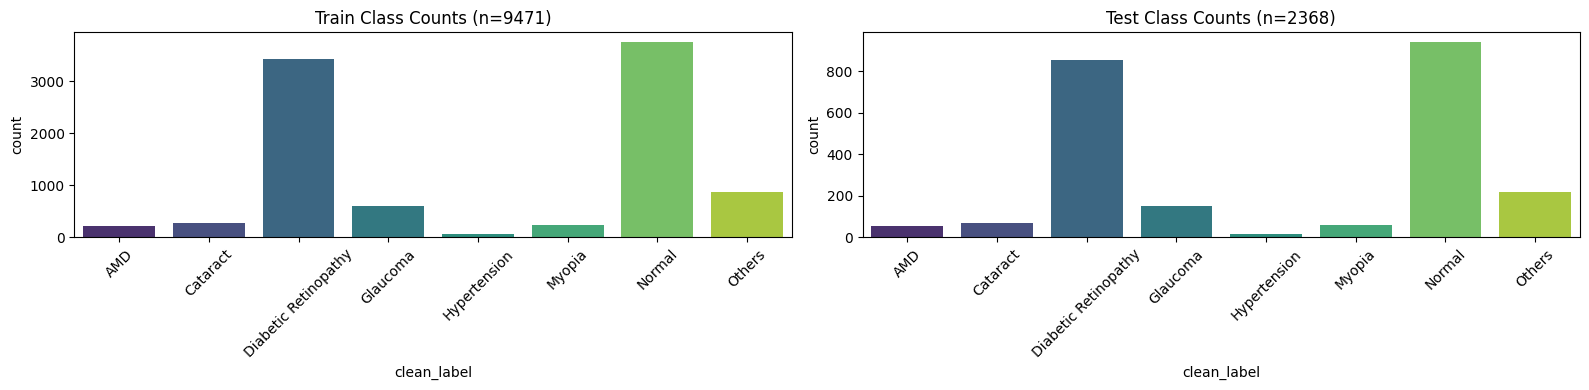

Train distribution:
 clean_label
Normal                  3758
Diabetic Retinopathy    3425
Others                   882
Glaucoma                 610
Cataract                 272
Myopia                   235
AMD                      219
Hypertension              70
Name: count, dtype: int64 

Test distribution:
 clean_label
Normal                  940
Diabetic Retinopathy    856
Others                  220
Glaucoma                152
Cataract                 68
Myopia                   59
AMD                      55
Hypertension             18
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
order = sorted(df['clean_label'].unique())

sns.countplot(data=train_df, x='clean_label', palette='viridis', ax=axes[0], order=order)
axes[0].set_title(f'Train Class Counts (n={len(train_df)})')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=test_df, x='clean_label', palette='viridis', ax=axes[1], order=order)
axes[1].set_title(f'Test Class Counts (n={len(test_df)})')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Train distribution:\n", train_df['clean_label'].value_counts(), "\n")
print("Test distribution:\n", test_df['clean_label'].value_counts())


## 10. Shared building blocks — preprocessing (with optional CLAHE), augmentation, oversampling, model, macro-F1

`crop_and_resize` is unchanged from v3 (content-crop + resize to 456, raw 0-255 float — `EfficientNetB5` rescales/normalizes internally, so no separate `preprocess_input` call is needed), reused identically for both stages. One addition merged in from the second notebook: an optional CLAHE green-channel contrast boost, gated behind `USE_CLAHE_ENHANCEMENT` (off by default) so it doesn't silently change what the model already works on.

In [17]:
IMG_SIZE = 300
BATCH_SIZE = 16

USE_CLAHE_ENHANCEMENT = False

def apply_clahe_green(img_uint8):
    #CLAHE on the green channel only (highest-contrast channel for retinal vessels),
    g_channel = img_uint8[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_g = clahe.apply(g_channel)
    enhanced_img = cv2.merge([img_uint8[:, :, 0], enhanced_g, img_uint8[:, :, 2]])
    return enhanced_img

def crop_and_resize(img_path):
    path = img_path.numpy().decode('utf-8')
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 8
    if np.any(mask):
        rows, cols = np.where(mask)
        img = img[rows.min():rows.max(), cols.min():cols.max()]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    if USE_CLAHE_ENHANCEMENT:
        img = apply_clahe_green(img.astype(np.uint8))
    return img.astype(np.float32)

def load_image(path, label, is_minority):
    img = tf.py_function(func=crop_and_resize, inp=[path], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label, is_minority

aggressive_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.30),
    layers.RandomTranslation(0.20, 0.20),
    layers.RandomContrast(0.35),
    layers.RandomBrightness(0.35),
], name="aggressive_augmentation")

mild_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="mild_augmentation")


I0000 00:00:1790354948.233201      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790354948.236123      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


**Preview: CLAHE-enhanced vs. standard preprocessing** — inspect before deciding whether to set `USE_CLAHE_ENHANCEMENT = True` above.

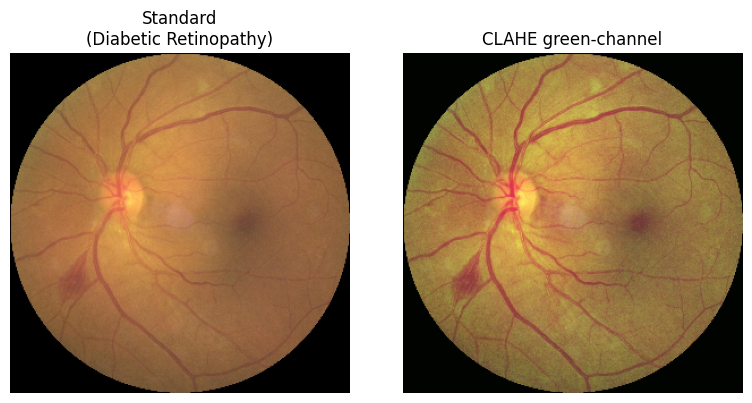

In [13]:
def preview_clahe(dataframe, class_name):
    sample_path = dataframe[dataframe['clean_label'] == class_name]['full_path'].iloc[0]
    path_tensor = tf.constant(sample_path)

    path = path_tensor.numpy().decode('utf-8')
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 8
    if np.any(mask):
        rows, cols = np.where(mask)
        img = img[rows.min():rows.max(), cols.min():cols.max()]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.uint8)
    img_clahe = apply_clahe_green(img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img); axes[0].set_title(f"Standard\n({class_name})"); axes[0].axis('off')
    axes[1].imshow(img_clahe); axes[1].set_title("CLAHE green-channel"); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

preview_clahe(train_df, 'Diabetic Retinopathy')


Reusable oversampling, class weights (with an optional manual override), and the `tf.data` pipeline factory — parameterized so Stage 1 and Stage 2 share the exact same code path.

In [19]:
def find_minority_majority(df_, label_col):
    class_counts = df_[label_col].value_counts()
    threshold = class_counts.median()
    minority_classes = class_counts[class_counts < threshold].index.tolist()
    majority_classes = class_counts[class_counts >= threshold].index.tolist()
    return class_counts, minority_classes, majority_classes

def oversample_minority(df_, minority_classes, label_col, target_count):
    parts = []
    for cls, cls_df in df_.groupby(label_col):
        if cls in minority_classes and len(cls_df) < target_count:
            cls_df = resample(cls_df, replace=True, n_samples=target_count, random_state=42)
        parts.append(cls_df)
    out = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
    out['is_minority'] = out[label_col].isin(minority_classes)
    return out

def compute_class_weight_tensor(train_df_aug, label_col, num_classes, manual_multipliers=None):
    """manual_multipliers: optional dict {class_index: multiplier}, merged from the old
    notebook's custom_multipliers -- lets domain knowledge boost specific hard classes on
    top of the automatic 'balanced' weights. None (default) reproduces v3 behavior exactly."""
    classes_encoded = np.sort(train_df_aug[label_col].unique())
    weights = compute_class_weight('balanced', classes=classes_encoded, y=train_df_aug[label_col])
    class_weight_dict = dict(zip(classes_encoded, weights))
    if manual_multipliers:
        for idx, mult in manual_multipliers.items():
            if idx in class_weight_dict:
                class_weight_dict[idx] *= mult
    print("Class weight dict:", class_weight_dict)
    return tf.constant([class_weight_dict.get(i, 1.0) for i in range(num_classes)], dtype=tf.float32)

def make_pipelines(num_classes, class_weight_tensor, label_col):
    def augment_train(img, label, is_minority):
        img_b = tf.expand_dims(img, 0)
        img_b = tf.cond(
            is_minority,
            lambda: aggressive_aug(img_b, training=True),
            lambda: mild_aug(img_b, training=True)
        )
        img_out = tf.squeeze(img_b, 0)
        sample_weight = tf.gather(class_weight_tensor, label)
        label_oh = tf.one_hot(label, num_classes)
        return img_out, label_oh, sample_weight

    def make_train_dataset(dataframe, encoded_col, batch_size=BATCH_SIZE):
        paths = dataframe['full_path'].values
        labels = dataframe[encoded_col].values
        is_minority_flags = dataframe['is_minority'].values

        ds = tf.data.Dataset.from_tensor_slices((paths, labels, is_minority_flags))
        ds = ds.shuffle(buffer_size=len(dataframe), reshuffle_each_iteration=True)
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(augment_train, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        return ds

    def make_eval_dataset(dataframe, encoded_col, batch_size=BATCH_SIZE):
        paths = dataframe['full_path'].values
        labels = dataframe[encoded_col].values
        is_minority_flags = np.zeros(len(dataframe), dtype=bool)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels, is_minority_flags))
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, label, is_min: (img, tf.one_hot(label, num_classes)),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        return ds

    return make_train_dataset, make_eval_dataset


In [24]:
def build_efficientnet_model(num_classes, name, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape, name="input_image")
    base_model = EfficientNetB5(include_top=False, weights='imagenet', input_tensor=inputs)
    base_model.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name=name)
    return model, base_model

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, val_labels):
        super().__init__()
        self.val_dataset = val_dataset
        self.val_labels = val_labels

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.val_dataset, verbose=0), axis=1)
        macro_f1 = f1_score(self.val_labels, preds, average='macro')
        print(f" -- val_macro_f1: {macro_f1:.4f}")
        if logs is not None:
            logs['val_macro_f1'] = macro_f1



def make_drive_checkpoint_callback(drive_dir='/content/drive/MyDrive/my_models'):

    os.makedirs(drive_dir, exist_ok=True)
    return ModelCheckpoint(
        filepath=os.path.join(drive_dir, 'checkpoint_epoch_{epoch:02d}.keras'),
        save_best_only=False,
    )


In [26]:
def plot_training_history(hist, title_suffix=""):
    hist = hist.history if hasattr(hist, 'history') else hist
    acc = hist.get('accuracy', [])
    val_acc = hist.get('val_accuracy', [])
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title(f'Accuracy {title_suffix}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title(f'Loss {title_suffix}')
    plt.legend()
    plt.show()

## 11. Stage 1 — build the Normal-vs-Disease dataset

In [27]:
class_counts_s1, minority_s1, majority_s1 = find_minority_majority(train_df, 'is_disease')
print("Stage 1 class counts:\n", class_counts_s1)
print("Minority (is_disease):", minority_s1, "| Majority:", majority_s1)

target_count_s1 = int(class_counts_s1[majority_s1].min()) if majority_s1 else int(class_counts_s1.max())
train_df_s1 = oversample_minority(train_df, minority_s1, label_col='is_disease', target_count=target_count_s1)
print("\nPost-oversampling Stage 1 counts:\n", train_df_s1['is_disease'].value_counts())



Stage 1 class counts:
 is_disease
1    5713
0    3758
Name: count, dtype: int64
Minority (is_disease): [0] | Majority: [1]

Post-oversampling Stage 1 counts:
 is_disease
0    5713
1    5713
Name: count, dtype: int64


In [28]:

NUM_CLASSES_S1 = 2
class_weight_tensor_s1 = compute_class_weight_tensor(train_df_s1, 'is_disease', NUM_CLASSES_S1)

make_train_ds_s1, make_eval_ds_s1 = make_pipelines(NUM_CLASSES_S1, class_weight_tensor_s1, 'is_disease')
train_ds_s1 = make_train_ds_s1(train_df_s1, encoded_col='is_disease')
test_ds_s1 = make_eval_ds_s1(test_df, encoded_col='is_disease')

Class weight dict: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


## 12. Stage 1 model — train head, then a light fine-tune

In [ ]:
model_s1, base_model_s1 = build_efficientnet_model(NUM_CLASSES_S1, name="Stage1_NormalVsDisease")

strategy = tf.distribute.MirroredStrategy()
print(f"Number of active devices: {strategy.num_replicas_in_sync}")


with strategy.scope():
    model_s1, base_model_s1 = build_efficientnet_model(
        NUM_CLASSES_S1, 
        name="Stage1_NormalVsDisease"
    )

    model_s1.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )


callbacks_s1_phase1 = [
    MacroF1Callback(test_ds_s1, test_df['is_disease'].values),
    # EarlyStopping(monitor='val_macro_f1', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_stage1_phase1.h5', monitor='val_macro_f1', mode='max', save_best_only=True),
]


history_s1_phase1 = model_s1.fit(
    train_ds_s1, 
    epochs=10, 
    validation_data=test_ds_s1, 
    callbacks=callbacks_s1_phase1
)

plot_training_history(history_s1_phase1, "-- Stage 1 Phase 1 (frozen backbone)")


In [ ]:
plot_training_history(history_s1_phase1, "-- Stage 1 Phase 1 (frozen backbone)")

In [ ]:
base_model_s1.trainable = True
FINE_TUNE_AT_S1 = len(base_model_s1.layers) - 20
for layer in base_model_s1.layers[:FINE_TUNE_AT_S1]:
    layer.trainable = False
for layer in base_model_s1.layers[FINE_TUNE_AT_S1:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

callbacks_s1_phase2 = [
    MacroF1Callback(test_ds_s1, test_df['is_disease'].values),
    EarlyStopping(monitor='val_macro_f1', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_stage1_phase2.h5', monitor='val_macro_f1', mode='max', save_best_only=True),
]

model_s1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_s1_phase2 = model_s1.fit(
    train_ds_s1, epochs=10, validation_data=test_ds_s1, callbacks=callbacks_s1_phase2
)
model_s1.save('stage1_normal_vs_disease.h5')
plot_training_history(history_s1_phase2, "-- Stage 1 Phase 2 (fine-tuned)")


## 13. Threshold tuning for Stage 1 — optimize for recall, not accuracy

A disease case Stage 1 misses never reaches Stage 2, so this sweeps the "disease" probability threshold and picks the smallest one that still hits `TARGET_RECALL`.

In [ ]:
TARGET_RECALL = 0.97

disease_probs = model_s1.predict(test_ds_s1)[:, 1]
y_true_s1 = test_df['is_disease'].values

precisions, recalls, thresholds = precision_recall_curve(y_true_s1, disease_probs)
valid_idx = np.where(recalls[:-1] >= TARGET_RECALL)[0]
if len(valid_idx) > 0:
    chosen_idx = valid_idx[np.argmax(thresholds[valid_idx])]
    STAGE1_THRESHOLD = float(thresholds[chosen_idx])
else:
    STAGE1_THRESHOLD = float(thresholds.min())
    print(f"WARNING: no threshold reaches recall >= {TARGET_RECALL}; using the lowest available threshold instead.")

print(f"Chosen Stage 1 threshold: {STAGE1_THRESHOLD:.3f}")
print(f"  -> recall:    {recalls[chosen_idx] if len(valid_idx) else recalls[0]:.3f}")
print(f"  -> precision: {precisions[chosen_idx] if len(valid_idx) else precisions[0]:.3f}")

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.axvline(TARGET_RECALL, color='red', linestyle='--', label=f'target recall={TARGET_RECALL}')
plt.xlabel('Recall (disease)')
plt.ylabel('Precision (disease)')
plt.title('Stage 1 Precision-Recall Tradeoff')
plt.legend()
plt.show()


## 14. Stage 2 — build the disease-type dataset, with a `Reject` safety class

Stage 2 also receives Stage-1 false positives at inference, so it's trained with a sampled `Reject` class (real Normal images) so it has a legitimate way to say "not one of my 7 diseases".

In [ ]:
disease_classes = [c for c in class_mapping if c != 'Normal'and c!= 'Others']
stage2_train_df = train_df[train_df['clean_label'] != 'Normal'or train_df['clean_label']!= 'Others'].copy()
stage2_test_df = test_df[test_df['clean_label'] != 'Normal' or train_df['clean_label']!= 'Others'].copy()

disease_class_counts = stage2_train_df['clean_label'].value_counts()
n_reject_train = int(disease_class_counts.median())
n_reject_test = max(1, int(n_reject_train * 0.2))

reject_pool_train = train_df[train_df['clean_label'] == 'Normal'].sample(
    n=min(n_reject_train, (train_df['clean_label'] == 'Normal').sum()), random_state=42
).copy()
reject_pool_test = test_df[test_df['clean_label'] == 'Normal'].sample(
    n=min(n_reject_test, (test_df['clean_label'] == 'Normal').sum()), random_state=42
).copy()

reject_pool_train['clean_label'] = 'Reject'
reject_pool_test['clean_label'] = 'Reject'

stage2_train_df = pd.concat([stage2_train_df, reject_pool_train]).sample(frac=1, random_state=42).reset_index(drop=True)
stage2_test_df = pd.concat([stage2_test_df, reject_pool_test]).sample(frac=1, random_state=42).reset_index(drop=True)

stage2_label_encoder = LabelEncoder()
stage2_train_df['stage2_label'] = stage2_label_encoder.fit_transform(stage2_train_df['clean_label'])
stage2_test_df['stage2_label'] = stage2_label_encoder.transform(stage2_test_df['clean_label'])
stage2_class_mapping = dict(zip(stage2_label_encoder.classes_, stage2_label_encoder.transform(stage2_label_encoder.classes_)))
NUM_CLASSES_S2 = len(stage2_class_mapping)

print("Stage 2 class mapping:", stage2_class_mapping)
print("\nStage 2 train counts:\n", stage2_train_df['clean_label'].value_counts())


## 15. Stage 2 — oversampling, class weights, and datasets

**Optional (merged from the old notebook):** `CUSTOM_STAGE2_MULTIPLIERS` lets you boost specific hard classes on top of the automatic `'balanced'` weights, e.g. if AMD/Hypertension/Others keep underperforming after the standard run. Leave it as `None` to reproduce plain balanced weighting.

In [ ]:
class_counts_s2, minority_s2, majority_s2 = find_minority_majority(stage2_train_df, 'clean_label')
target_count_s2 = int(class_counts_s2[majority_s2].min())
stage2_train_df_aug = oversample_minority(stage2_train_df, minority_s2, label_col='clean_label', target_count=target_count_s2)

print(f"Stage 2 target count: {target_count_s2}")
print("Stage 2 minority classes:", minority_s2, "| majority:", majority_s2)
print("\nPost-oversampling Stage 2 counts:\n", stage2_train_df_aug['clean_label'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=stage2_train_df_aug, x='clean_label', palette='viridis',
              order=sorted(stage2_train_df_aug['clean_label'].unique()))
plt.title('Stage 2 Train Class Counts After Oversampling')
plt.xticks(rotation=45)
plt.show()

# Optional manual override, e.g.: {stage2_class_mapping['AMD']: 1.5, stage2_class_mapping['Hypertension']: 1.5}
CUSTOM_STAGE2_MULTIPLIERS = None

class_weight_tensor_s2 = compute_class_weight_tensor(
    stage2_train_df_aug, 'stage2_label', NUM_CLASSES_S2, manual_multipliers=CUSTOM_STAGE2_MULTIPLIERS
)

make_train_ds_s2, make_eval_ds_s2 = make_pipelines(NUM_CLASSES_S2, class_weight_tensor_s2, 'stage2_label')
train_ds_s2 = make_train_ds_s2(stage2_train_df_aug, encoded_col='stage2_label')
test_ds_s2 = make_eval_ds_s2(stage2_test_df, encoded_col='stage2_label')


## 16. Stage 2 model — train head, then fine-tune

In [ ]:
model_s2, base_model_s2 = build_efficientnet_model(NUM_CLASSES_S2, name="Stage2_DiseaseType")

callbacks_s2_phase1 = [
    MacroF1Callback(test_ds_s2, stage2_test_df['stage2_label'].values),
    EarlyStopping(monitor='val_macro_f1', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_stage2_phase1.h5', monitor='val_macro_f1', mode='max', save_best_only=True),
]

model_s2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_s2_phase1 = model_s2.fit(
    train_ds_s2, epochs=20, validation_data=test_ds_s2, callbacks=callbacks_s2_phase1
)
plot_training_history(history_s2_phase1, "-- Stage 2 Phase 1 (frozen backbone)")


In [ ]:
base_model_s2.trainable = True
FINE_TUNE_AT_S2 = len(base_model_s2.layers) - 40
for layer in base_model_s2.layers[:FINE_TUNE_AT_S2]:
    layer.trainable = False
for layer in base_model_s2.layers[FINE_TUNE_AT_S2:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

callbacks_s2_phase2 = [
    MacroF1Callback(test_ds_s2, stage2_test_df['stage2_label'].values),
    EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_stage2_phase2.h5', monitor='val_macro_f1', mode='max', save_best_only=True),
]

model_s2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_s2_phase2 = model_s2.fit(
    train_ds_s2, epochs=20, validation_data=test_ds_s2, callbacks=callbacks_s2_phase2
)
model_s2.save('stage2_disease_type.h5')
plot_training_history(history_s2_phase2, "-- Stage 2 Phase 2 (fine-tuned)")


## 17. End-to-end pipeline evaluation

Runs the full Stage1 -> Stage2 chain on the original `test_df` (true 8-class labels), not either stage's own isolated set.

In [ ]:
def run_full_pipeline(df_eval, model_s1, model_s2, stage1_threshold, stage2_inv_mapping, batch_size=BATCH_SIZE):
    eval_ds_raw = tf.data.Dataset.from_tensor_slices((df_eval['full_path'].values,
                                                        np.zeros(len(df_eval), dtype=np.int32),
                                                        np.zeros(len(df_eval), dtype=bool)))
    eval_ds_raw = eval_ds_raw.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    imgs_only = eval_ds_raw.map(lambda img, label, is_min: img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    disease_probs = model_s1.predict(imgs_only, verbose=0)[:, 1]
    routed_to_disease = disease_probs >= stage1_threshold

    final_preds = np.array(['Normal'] * len(df_eval), dtype=object)

    if routed_to_disease.any():
        disease_rows = df_eval[routed_to_disease]
        disease_imgs_ds = tf.data.Dataset.from_tensor_slices((disease_rows['full_path'].values,
                                                                np.zeros(len(disease_rows), dtype=np.int32),
                                                                np.zeros(len(disease_rows), dtype=bool)))
        disease_imgs_ds = disease_imgs_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        disease_imgs_ds = disease_imgs_ds.map(lambda img, label, is_min: img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

        s2_pred_idx = np.argmax(model_s2.predict(disease_imgs_ds, verbose=0), axis=1)
        s2_pred_labels = np.array([stage2_inv_mapping[i] for i in s2_pred_idx], dtype=object)
        s2_pred_labels[s2_pred_labels == 'Reject'] = 'Normal'

        final_preds[routed_to_disease] = s2_pred_labels

    return final_preds, disease_probs, routed_to_disease

stage2_inv_mapping = {v: k for k, v in stage2_class_mapping.items()}
final_preds, disease_probs, routed_to_disease = run_full_pipeline(
    test_df, model_s1, model_s2, STAGE1_THRESHOLD, stage2_inv_mapping
)

y_true_full = test_df['clean_label'].values
class_order = sorted(class_mapping.keys())

print("--- Stage 1 alone: Normal-vs-Disease recall/precision at the chosen threshold ---")
print(classification_report(test_df['is_disease'].values, routed_to_disease.astype(int),
                             target_names=['Normal', 'Disease']))

print("\n--- Full pipeline: 8-class report on the ORIGINAL test set ---")
print(classification_report(y_true_full, final_preds, labels=class_order, target_names=class_order))
print("Pipeline Macro F1:", f1_score(y_true_full, final_preds, labels=class_order, average='macro'))

cm = confusion_matrix(y_true_full, final_preds, labels=class_order)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_order, yticklabels=class_order)
plt.title('End-to-End Pipeline Confusion Matrix (vs. original 8-class labels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


##  scratch CNN baseline, no transfer learning

**Merged from the old notebook's `build_scratch_functional_cnn`.** Not part of the cascade — a reference point to check whether the EfficientNetB5 cascade is actually worth its extra cost versus a small CNN trained from random weights on the plain 8-class problem. Reuses the same `crop_and_resize`/pipeline factory as everything above, so the comparison is apples-to-apples. Expect it to train slower per step than the frozen-backbone phases and to plateau lower, since it isn't starting from ImageNet features.

In [ ]:
def build_scratch_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES_FULL):
    inputs = layers.Input(shape=input_shape, name="input_image")
    x = layers.Rescaling(1. / 255, name="rescaling")(inputs)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)
    return Model(inputs=inputs, outputs=outputs, name="ScratchCNN_Baseline")

class_counts_full, minority_full, majority_full = find_minority_majority(train_df, 'clean_label')
target_count_full = int(class_counts_full[majority_full].min())
train_df_full_aug = oversample_minority(train_df, minority_full, label_col='clean_label', target_count=target_count_full)

class_weight_tensor_full = compute_class_weight_tensor(train_df_full_aug, 'encoded_label', NUM_CLASSES_FULL)
make_train_ds_full, make_eval_ds_full = make_pipelines(NUM_CLASSES_FULL, class_weight_tensor_full, 'encoded_label')
train_ds_full = make_train_ds_full(train_df_full_aug, encoded_col='encoded_label')
test_ds_full = make_eval_ds_full(test_df, encoded_col='encoded_label')

scratch_model = build_scratch_cnn()
scratch_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_scratch = [
    MacroF1Callback(test_ds_full, test_df['encoded_label'].values),
    EarlyStopping(monitor='val_macro_f1', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_scratch_cnn.h5', monitor='val_macro_f1', mode='max', save_best_only=True),
]

history_scratch = scratch_model.fit(
    train_ds_full, epochs=15, validation_data=test_ds_full, callbacks=callbacks_scratch
)
scratch_model.save('scratch_cnn_baseline.h5')
plot_training_history(history_scratch, "-- Scratch CNN baseline")

print("\nCompare this Macro F1 against 'Pipeline Macro F1' printed ")


## 19. Save / download models

In [ ]:
from IPython.display import FileLink
FileLink('stage1_normal_vs_disease.h5')


In [ ]:
FileLink('stage2_disease_type.h5')
